## Owl-ViT

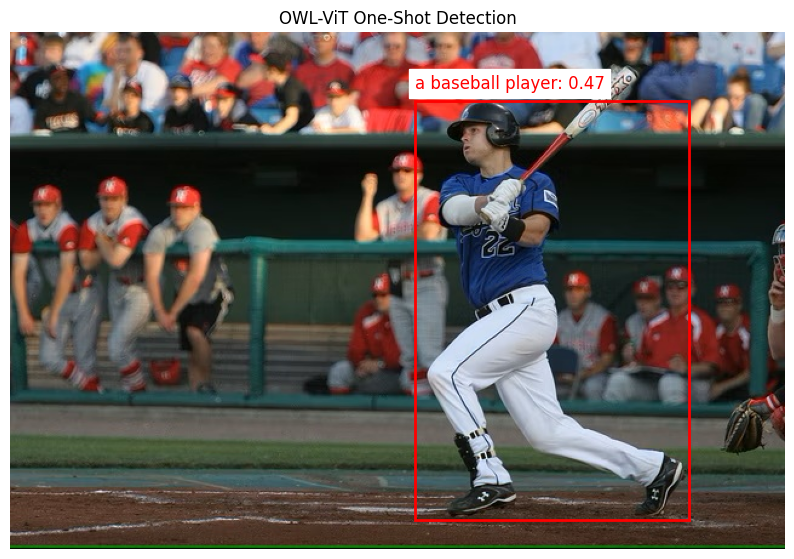

In [15]:
import torch
from transformers import OwlViTProcessor, OwlViTForObjectDetection
from PIL import Image
import requests
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ---- Load OWL-ViT ----
model = OwlViTForObjectDetection.from_pretrained("google/owlvit-base-patch32")
processor = OwlViTProcessor.from_pretrained("google/owlvit-base-patch32")

# ---- Load image (replace with your own if needed) ----
# Reemplaza con la ruta local de tu imagen
image_path = "example_image.jpg"
#image_path = "COCO1.jpg"
#image_path = "COCO2.jpg"
image = Image.open(image_path).convert("RGB")

#image_url = "https://storage.googleapis.com/mediapipe-assets/owlvit/example_dog.jpg"
#image = Image.open(requests.get(image_url, stream=True).raw).convert("RGB")

# ---- Text prompt for one-shot detection ----
# You can modify the prompts as needed
#text_prompts = [["a catcher glove"]]
text_prompts = [["a baseball player"]]
#text_prompts = [["a baseball bat"]]
#text_prompts = [["a dog"]]
#text_prompts = [["a tennis racket"]]

# ---- Preprocess inputs ----
inputs = processor(text=text_prompts, images=image, return_tensors="pt")

# ---- Forward pass ----
with torch.no_grad():
    outputs = model(**inputs)

# ---- Post-process outputs ----
target_sizes = torch.tensor([image.size[::-1]])  # (H, W)
results = processor.post_process_object_detection(outputs=outputs, target_sizes=target_sizes, threshold=0.3)

# ---- Visualization ----
boxes, scores, labels = results[0]["boxes"], results[0]["scores"], results[0]["labels"]

plt.figure(figsize=(10, 10))
plt.imshow(image)
ax = plt.gca()

for box, score, label in zip(boxes, scores, labels):
    xmin, ymin, xmax, ymax = box
    width, height = xmax - xmin, ymax - ymin
    ax.add_patch(patches.Rectangle((xmin, ymin), width, height, linewidth=2, edgecolor='r', facecolor='none'))
    ax.text(xmin, ymin - 10, f"{text_prompts[0][label]}: {score:.2f}", color='red', fontsize=12, backgroundcolor="white")

plt.axis("off")
plt.title("OWL-ViT One-Shot Detection")
plt.show()


Exercise

- Implement the code to save the resultant image with predictions.
- Change the image, the prompt and the threshold and see the results.
- Do the prediction with a COCO image from the Internet using the suggested code, comment the results.
- Do the prediction but this time with a more scarce image, comment the results.
- Do the prediction with a longer prompt, comment the result.
- Do the prediction with a prompt in spanish, comment the result.
  